In [15]:
# Load data first
df = pd.read_csv('data/edaall.csv')

# Filter for luxury properties for better hotspot visualization
df_luxury = df[(df['grade'] >= 10) & (df['condition'] >= 3)]

print("Dataset Info:")
print(f"Total properties: {len(df)}")
print(f"Luxury properties (Grade 10+, Condition 3+): {len(df_luxury)}")
print(f"\nLatitude range: {df['lat'].min():.4f} to {df['lat'].max():.4f}")
print(f"Longitude range: {df['long'].min():.4f} to {df['long'].max():.4f}")
print(f"Price range: ${df['price'].min():,.0f} to ${df['price'].max():,.0f}")

Dataset Info:
Total properties: 21597
Luxury properties (Grade 10+, Condition 3+): 1633

Latitude range: 47.1559 to 47.7776
Longitude range: -122.5190 to -121.3150
Price range: $78,000 to $7,700,000


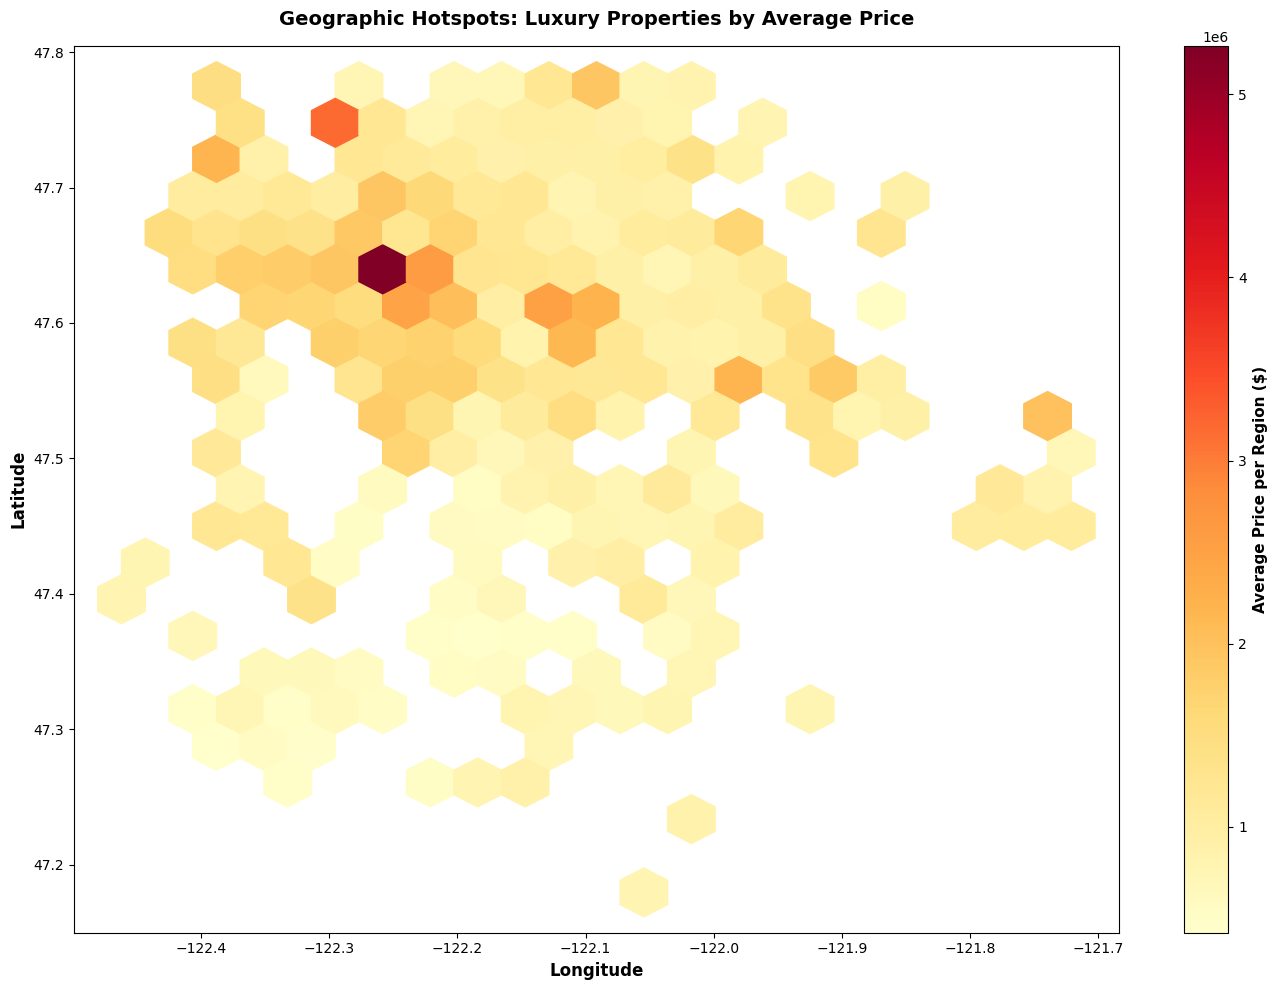


HEXBIN PLOT EXPLANATION

📍 WHAT EACH COLOR MEANS:
   • YELLOW hexagons = Lower average prices in that geographic region
   • ORANGE hexagons = Medium average prices
   • DARK RED hexagons = HIGHEST average prices (LUXURY HOTSPOTS!)

🎯 DARKEST RED SPOTS INDICATE:
   • Geographic clusters with the most expensive properties
   • Neighborhoods commanding premium prices
   • Best neighborhoods for luxury investors like Jennifer


In [ ]:
# --- HEXBIN PLOT: Geographic Hotspots by Price ---
import numpy as np

fig, ax = plt.subplots(figsize=(14, 10))

# Create hexbin plot
hexbin = ax.hexbin(
    df_luxury['long'], 
    df_luxury['lat'], 
    C=df_luxury['price'],  # Color by price
    gridsize=20,           # Number of hexagons
    cmap='YlOrRd',         # Yellow → Orange → Red (low → high price)
    mincnt=1,              # Minimum count per hex
    reduce_C_function=np.mean  # Use MEAN price per hex
)

ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
ax.set_title('Geographic Hotspots: Luxury Properties by Average Price', 
             fontsize=14, fontweight='bold', pad=15)

cbar = plt.colorbar(hexbin, ax=ax)
cbar.set_label('Average Price per Region ($)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("HEXBIN PLOT EXPLANATION")
print("="*80)
print("\n📍 WHAT EACH COLOR MEANS:")
print("   • YELLOW hexagons = Lower average prices in that geographic region")
print("   • ORANGE hexagons = Medium average prices")
print("   • DARK RED hexagons = HIGHEST average prices (LUXURY HOTSPOTS!)")
print("\n🎯 DARKEST RED SPOTS INDICATE:")
print("   • Geographic clusters with the most expensive properties")
print("   • Neighborhoods commanding premium prices")
print("   • Best neighborhoods for luxury investors like Jennifer")

In [22]:
# --- EXTRACT HOTSPOT REGIONS FROM HEXBIN DATA ---
print("\n" + "="*80)
print("STEP 1: IDENTIFY HOTSPOT REGIONS")
print("="*80)

# Calculate average price per geographic area (by rounding coordinates)
# This approximates the hexbin grid
df_luxury['lat_bin'] = pd.cut(df_luxury['lat'], bins=20)
df_luxury['long_bin'] = pd.cut(df_luxury['long'], bins=20)

# Group by bins to find high-price regions
region_analysis = df_luxury.groupby(['lat_bin', 'long_bin']).agg({
    'price': ['mean', 'count', 'max'],
    'grade': 'mean',
    'condition': 'mean'
}).round(0)

region_analysis.columns = ['avg_price', 'count', 'max_price', 'avg_grade', 'avg_condition']
region_analysis = region_analysis.sort_values('avg_price', ascending=False)

# Show top 5 hotspot regions
print("\nTOP 5 HOTSPOT REGIONS (by average price):")
print(region_analysis.head())

# Extract the MOST EXPENSIVE region (darkest red spot)
top_region = region_analysis.index[0]
lat_range = top_region[0]
long_range = top_region[1]

print(f"\n🔴 DARKEST RED SPOT (Most Expensive Region):")
print(f"   Latitude range:  {lat_range.left:.4f} to {lat_range.right:.4f}")
print(f"   Longitude range: {long_range.left:.4f} to {long_range.right:.4f}")
print(f"   Average Price:   ${region_analysis.iloc[0]['avg_price']:,.0f}")
print(f"   Properties:      {int(region_analysis.iloc[0]['count'])} homes")
print(f"   Avg Grade:       {region_analysis.iloc[0]['avg_grade']:.1f}")
print(f"   Avg Condition:   {region_analysis.iloc[0]['avg_condition']:.1f}")


STEP 1: IDENTIFY HOTSPOT REGIONS


NameError: name 'df_luxury' is not defined

# Extracting data from server
## Understanding the Kings County housing range Data

# EDA

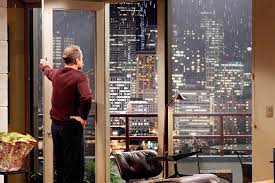

Target customer is Jennifer Montgomery. She wants High budget, wants to show off, timing within a month, waterfront, renovated, high grades, resell within 1 year

I have imported the list of houses based on budget, size, year of construction etc to match her requirements

In [23]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

Importing the csv files from postgresql

In [56]:
import psycopg2

import os
from dotenv import load_dotenv

load_dotenv()

DATABASE = os.getenv("DATABASE")
USER_DB = os.getenv("USER_DB")
PASSWORD = os.getenv("PASSWORD")
HOST = os.getenv("HOST")
PORT = os.getenv("PORT")

print(PORT if PORT != 0 else 'Error in connection')

5432


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

print('Libraries loaded successfully!')
print(f'  pandas  : {pd.__version__}')
print(f'  seaborn : {sns.__version__}')
import matplotlib; print(f'  matplotlib: {matplotlib.__version__}')
import plotly; print(f'  plotly  : {plotly.__version__}')

Libraries loaded successfully!
  pandas  : 2.2.3
  seaborn : 0.13.2
  matplotlib: 3.10.8
  plotly  : 6.7.0


In [33]:
# Create connection object conn
conn = psycopg2.connect(
    database=DATABASE, user=USER_DB, password=PASSWORD, host=HOST, port=PORT
)

cur = conn.cursor()

In [34]:
# import the complete data into a pandas dataframe to plot hypothesis
query_string = """
SELECT 
    *
FROM  eda.king_county_house_details kchd 
LEFT JOIN 
    eda.king_county_house_sales kchs ON kchs.house_id = kchd.id 
ORDER BY kchs.price DESC
"""
df_psycopg = pd.read_sql(query_string, conn)

In [33]:
# import the data into a pandas dataframe
query_jennifer = """
SELECT 
    kchs.house_id,
    kchs.price,
    kchd.sqft_above,
    kchd.sqft_basement,
    kchd.yr_renovated,
    kchd.grade,
    kchd.condition,
    kchd.waterfront,
    kchd.lat,
    kchd.long
FROM eda.king_county_house_sales kchs
FULL JOIN eda.king_county_house_details kchd 
    ON kchd.id = kchs.house_id
WHERE 
    kchd.waterfront = 1           -- Waterfront only
    AND kchd.grade >= 9           -- High grades
    AND kchd.condition >= 3       -- Good condition
    AND kchd.sqft_above > 2500    -- Spacious
    AND kchd.yr_renovated >= 2015 -- Recently renovated (or new)
    AND kchs.price >= 500000      -- High budget
ORDER BY kchs.price DESC
"""
df_psycopg = pd.read_sql(query_jennifer, conn)

In [35]:
# close the connection
conn.close()

In [36]:
df_psycopg.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,house_id,id
0,6762700020,6.000,8.000,12050.000,27600.000,2.500,0.000,3.000,4,13,...,19870.000,98102,47.630,-122.323,3940.000,8800.000,2014-10-13,7700000.000,6762700020,7246
1,9808700762,5.000,4.500,10040.000,37325.000,2.000,1.000,2.000,3,11,...,20010.000,98004,47.650,-122.214,3930.000,25449.000,2014-06-11,7060000.000,9808700762,3911
2,9208900037,6.000,7.750,9890.000,31374.000,2.000,0.000,4.000,3,13,...,0.000,98039,47.630,-122.240,4540.000,42730.000,2014-09-19,6890000.000,9208900037,9246
3,2470100110,5.000,5.750,9200.000,35069.000,2.000,0.000,0.000,3,13,...,NaN,98039,47.629,-122.233,3560.000,24345.000,2014-08-04,5570000.000,2470100110,4408
4,8907500070,5.000,5.000,8000.000,23985.000,2.000,0.000,4.000,3,12,...,0.000,98004,47.623,-122.220,4600.000,21750.000,2015-04-13,5350000.000,8907500070,1447


In [38]:
# export the complete data to a csv-file
df_psycopg.to_csv("data/edaall.csv", index=False)

In [38]:
# export the data to a csv-file
df_psycopg.to_csv("data/eda.csv", index=False)

In [55]:
#Code begins here for the assignment
# --- Load the Kings county housing dataset ---
# The CSV is stored locally in the data/ folder
df = pd.read_csv('data/eda.csv')
df.shape
#df.info()
df['yr_renovated'] = (df['yr_renovated'] / 10).astype('Int64')
df.head()


,house_id,price,sqft_above,sqft_basement,yr_renovated,grade,condition,waterfront,lat,long
0,9808700762,7060000.000,7680.000,2360.000,2001,11,3,1.000,47.650,-122.214
1,1924059029,4670000.000,4820.000,4820.000,2009,12,3,1.000,47.557,-122.210
2,4114601570,3600000.000,3420.000,1600.000,2002,10,3,1.000,47.593,-122.287
3,5442300807,2700000.000,3831.000,0.000,1980,9,3,1.000,47.592,-122.251
4,9201300050,1850000.000,2800.000,0.000,2001,9,3,1.000,47.578,-122.076


In [57]:
#Code begins here for the assignment
# --- Load the Kings county housing dataset ---
# The CSV is stored locally in the data/ folder
# --- Load the Palmer Penguins dataset ---
# The CSV is stored locally in the data/ folder
df_all = pd.read_csv('data/edaall.csv')
df_all.shape
#df.info()
df_all['yr_renovated'] = (df_all['yr_renovated'] / 10).astype('Int64')
df_all.head()


,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,house_id,id.1
0,6762700020,6.000,8.000,12050.000,27600.000,2.500,0.000,3.000,4,13,...,1987,98102,47.630,-122.323,3940.000,8800.000,2014-10-13,7700000.000,6762700020,7246
1,9808700762,5.000,4.500,10040.000,37325.000,2.000,1.000,2.000,3,11,...,2001,98004,47.650,-122.214,3930.000,25449.000,2014-06-11,7060000.000,9808700762,3911
2,9208900037,6.000,7.750,9890.000,31374.000,2.000,0.000,4.000,3,13,...,0,98039,47.630,-122.240,4540.000,42730.000,2014-09-19,6890000.000,9208900037,9246
3,2470100110,5.000,5.750,9200.000,35069.000,2.000,0.000,0.000,3,13,...,<NA>,98039,47.629,-122.233,3560.000,24345.000,2014-08-04,5570000.000,2470100110,4408
4,8907500070,5.000,5.000,8000.000,23985.000,2.000,0.000,4.000,3,12,...,0,98004,47.623,-122.220,4600.000,21750.000,2015-04-13,5350000.000,8907500070,1447


After we fetched two set of data. one with all available houses and one narrowed down as per client request
#Next we will plot the data as per hypothesis to narrow down the values towards our final result

In [42]:
# --- Check for missing values ---
# Missing values can silently affect plots, so always check first
missing = df_all.isna().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'ZERO — clean dataset!')

Missing values per column:
waterfront       2391
view               63
sqft_basement     452
yr_renovated     3848
dtype: int64


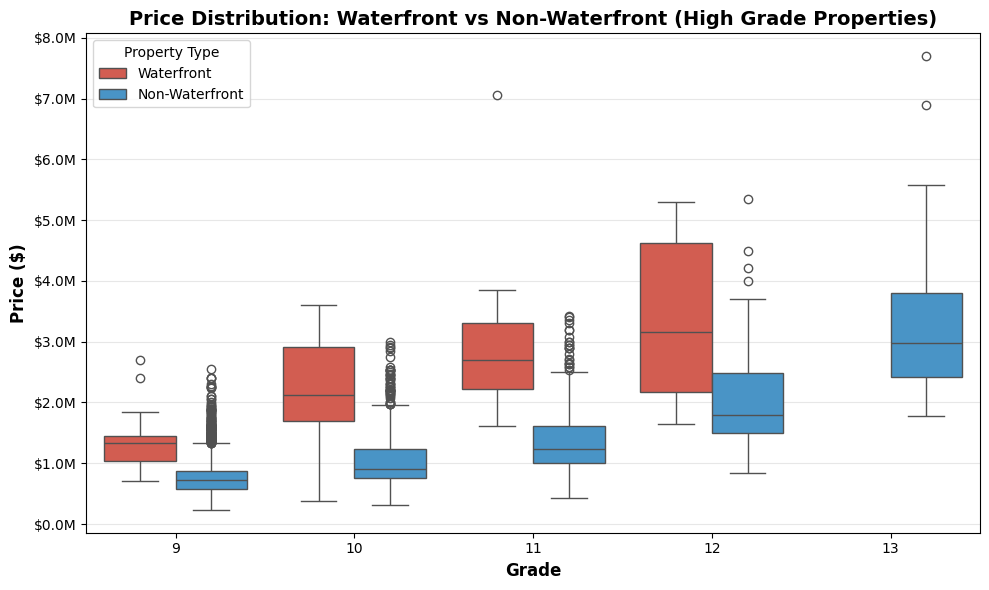

In [58]:
# --- Axes-level scatter: bill length vs flipper length, coloured by species ---
# Box plot samples.
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for waterfront premium properties (Grade >= 9)
premium_data = df_all[df_all['grade'] >= 9].copy()
premium_data['Type'] = premium_data['waterfront'].map({1: 'Waterfront', 0: 'Non-Waterfront'})

sns.boxplot(
    data=premium_data,
    x='grade',
    y='price',
    hue='Type',
    palette={'Waterfront': '#e74c3c', 'Non-Waterfront': '#3498db'},
    ax=ax
)

ax.set_title('Price Distribution: Waterfront vs Non-Waterfront (High Grade Properties)', fontsize=14, fontweight='bold')
ax.set_xlabel('Grade', fontsize=12, fontweight='bold')
ax.set_ylabel('Price ($)', fontsize=12, fontweight='bold')
ax.legend(title='Property Type', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

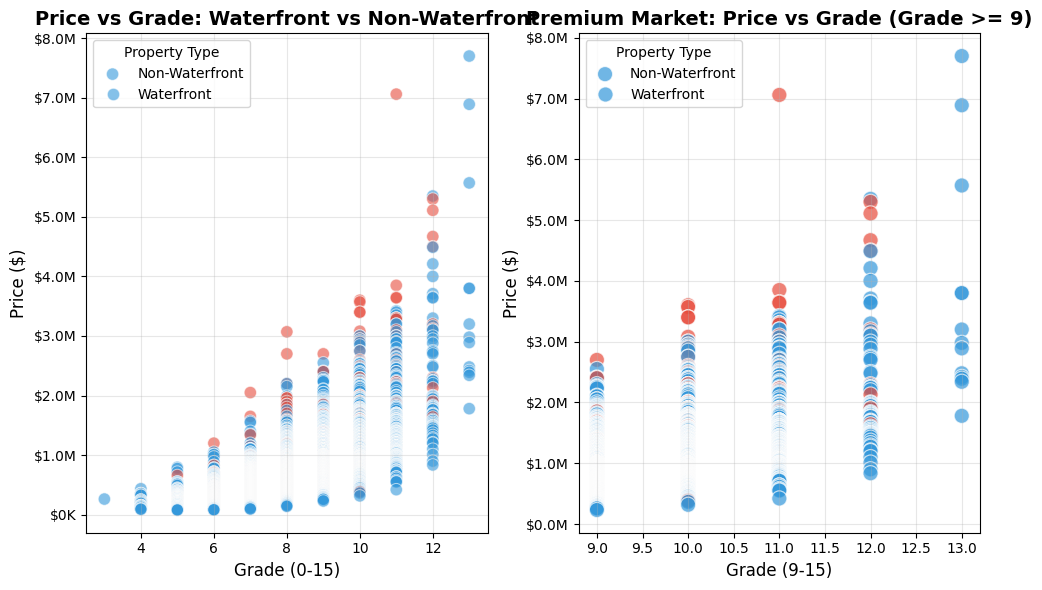

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# Left plot: All properties
sns.scatterplot(
    data=df_all,
    x='grade',
    y='price',
    hue='waterfront',
    palette={0: '#3498db', 1: '#e74c3c'},
    s=80,
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_title('Price vs Grade: Waterfront vs Non-Waterfront', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Grade (0-15)', fontsize=12)
axes[0].set_ylabel('Price ($)', fontsize=12)
axes[0].legend(title='Property Type', labels=['Non-Waterfront', 'Waterfront'])
axes[0].grid(True, alpha=0.3)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))

# Right plot: Only high-grade properties (Grade >= 9)
sns.scatterplot(
    data=df_all[df_all['grade'] >= 9],
    x='grade',
    y='price',
    hue='waterfront',
    palette={0: '#3498db', 1: '#e74c3c'},
    s=120,
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title('Premium Market: Price vs Grade (Grade >= 9)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Grade (9-15)', fontsize=12)
axes[1].set_ylabel('Price ($)', fontsize=12)
axes[1].legend(title='Property Type', labels=['Non-Waterfront', 'Waterfront'])
axes[1].grid(True, alpha=0.3)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

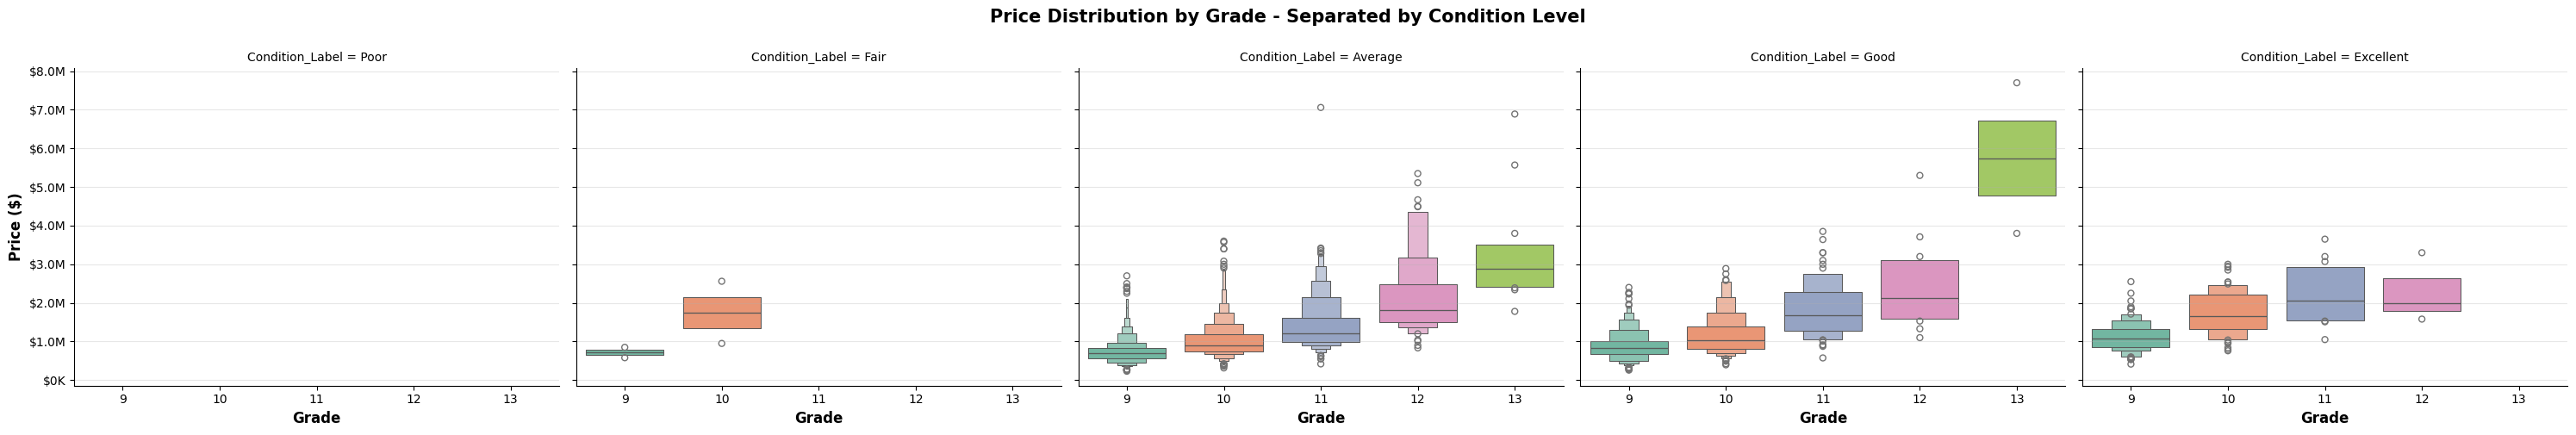

In [63]:
# --- SEABORN PLOT 5: Catplot (Facet Grid) - Side-by-side Condition Comparison ---

condition_map = {1: 'Poor', 2: 'Fair', 3: 'Average', 4: 'Good', 5: 'Excellent'}
df_cat = df_all[(df_all['grade'] >= 9) & (df_all['grade'] <= 13)].copy()
df_cat['Condition_Label'] = df_cat['condition'].map(condition_map)

# Create catplot with subplots for each condition
g = sns.catplot(
    data=df_cat,
    x='grade',
    y='price',
    kind='boxen',  # violin alternative - better for skewed data
    col='Condition_Label',
    col_order=['Poor', 'Fair', 'Average', 'Good', 'Excellent'],
    palette='Set2',
    height=5,
    aspect=1.2,
    sharey=True
)

g.set_axis_labels('Grade', 'Price ($)', fontsize=12, fontweight='bold')
g.fig.suptitle('Price Distribution by Grade - Separated by Condition Level', 
               fontsize=15, fontweight='bold', y=1.00)

# Format y-axis
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

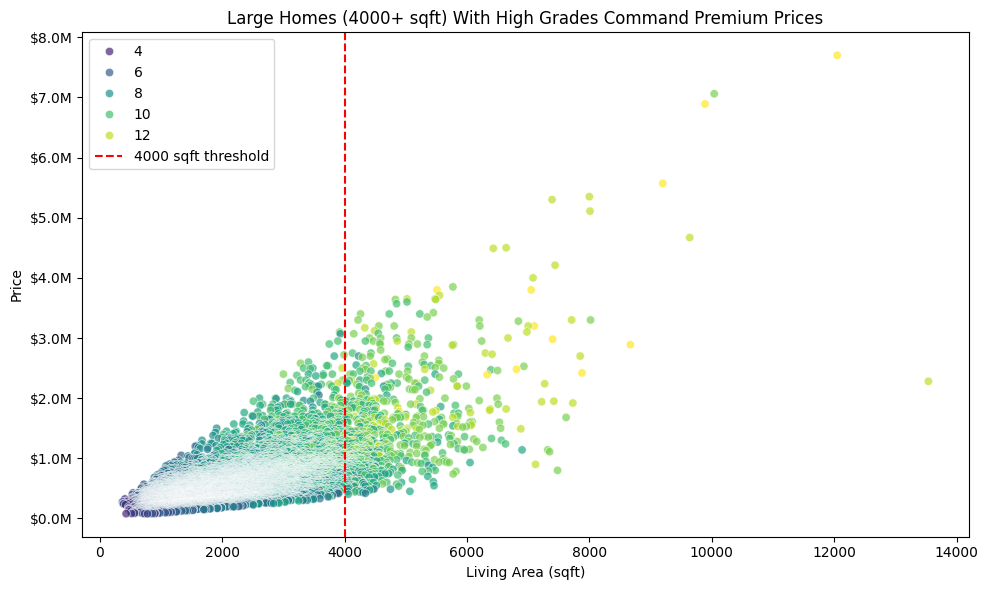

In [69]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
        data=df_all,
        x='sqft_living',
        y='price',
        hue='grade',
        palette='viridis',
        alpha=0.7
)

ax.vlines = plt.axvline(4000, color='red', linestyle='--', label='4000 sqft threshold')
ax.set_title = plt.title("Large Homes (4000+ sqft) With High Grades Command Premium Prices")
ax.set_xlabel = plt.xlabel("Living Area (sqft)")
ax.set_ylabel = plt.ylabel("Price")
ax.legend = plt.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.show()




In [70]:
tier = df_all[(df_all['grade'] >= 9) & (df_all['condition'] > 4) & (df_all['sqft_living'] > 4000) & (df_all['waterfront'] == 1)].copy()
len(tier)
print(f":${tier['price'].mean():,.0f}")

:$3,325,000


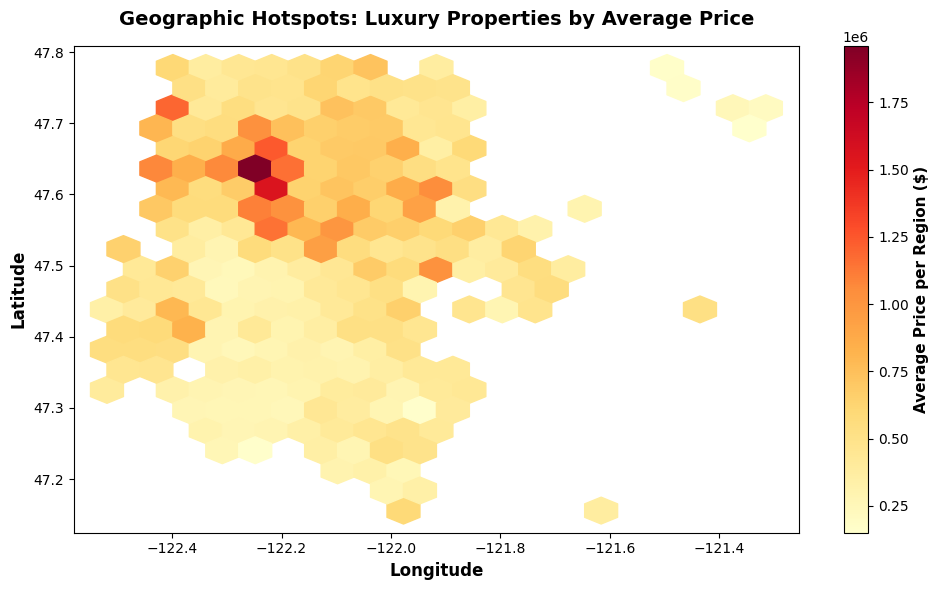

In [49]:
fig, ax = plt.subplots(figsize=(10, 6))

# Create hexbin plot
hexbin = ax.hexbin(
    df_all['long'], 
    df_all['lat'], 
    C=df_all['price'], 
    gridsize=20, 
    cmap='YlOrRd',        # Yellow → Orange → Red (low → high price)
    mincnt=1,              # Minimum count per hex
    reduce_C_function=np.mean  # Use MEAN price per hex
)

ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
ax.set_title('Geographic Hotspots: Luxury Properties by Average Price', 
             fontsize=14, fontweight='bold', pad=15)

cbar = plt.colorbar(hexbin, ax=ax)
cbar.set_label('Average Price per Region ($)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()



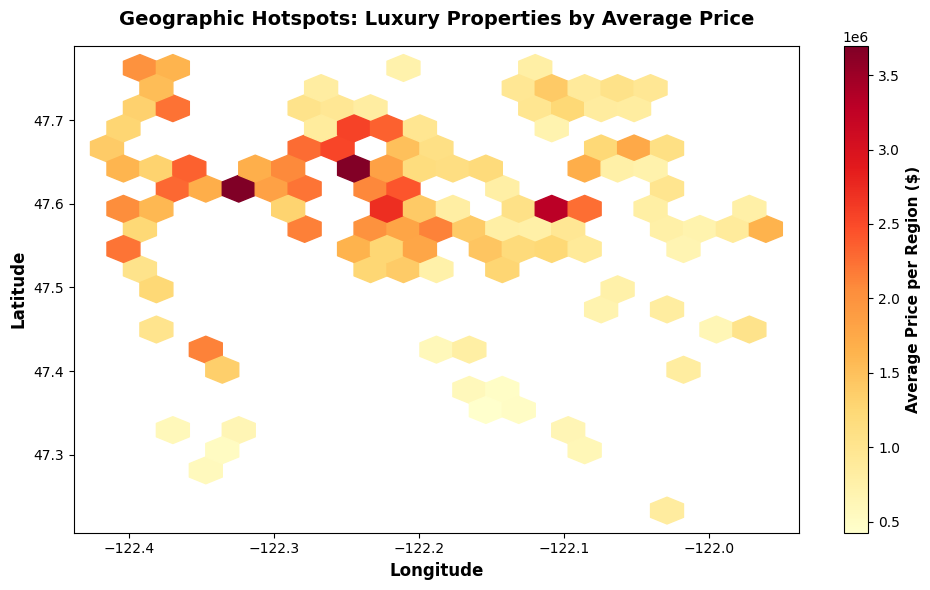

In [66]:
#Condition vs Gegraphical position scattered with price

df_georange = df_all[(df_all['grade'] >= 10) & (df_all['condition'] >= 4)].copy()

fig, ax = plt.subplots(figsize=(10, 6))

# Create hexbin plot
hexbin = ax.hexbin(
    df_georange['long'], 
    df_georange['lat'], 
    C=df_georange['price'], 
    gridsize=20, 
    cmap='YlOrRd',        # Yellow → Orange → Red (low → high price)
    mincnt=1,              # Minimum count per hex
    reduce_C_function=np.mean  # Use MEAN price per hex
)

ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
ax.set_title('Geographic Hotspots: Luxury Properties by Average Price', 
             fontsize=14, fontweight='bold', pad=15)

cbar = plt.colorbar(hexbin, ax=ax)
cbar.set_label('Average Price per Region ($)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

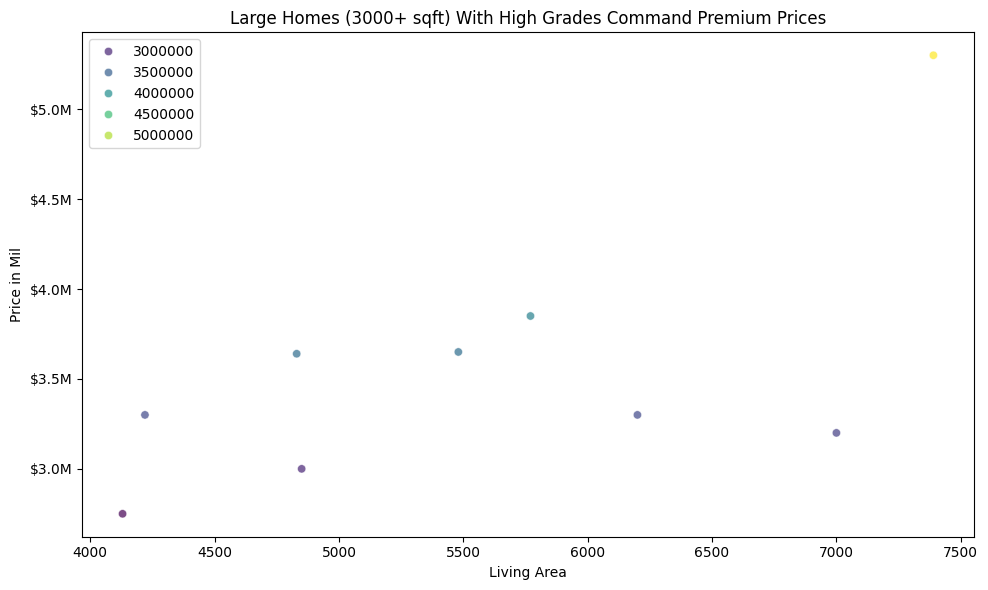

In [71]:
df_besths = df_all[(df_all['grade'] >= 10) & (df_all['condition'] >= 4) & (df_all['sqft_living'] >= 4000) & 
                   (df_all['long'] <= -122.0)& (df_all['lat'] >= 47.5)  & (df_all['waterfront'] == 1)].copy()

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df_besths,
    x='sqft_living',
    y='price',
    hue='price',
    palette='viridis',
    alpha=0.7
)

#plt.axvline(3000, color='red', linestyle='--', label='3000 sqft threshold')
ax.set_title = plt.title("Large Homes (3000+ sqft) With High Grades Command Premium Prices")
ax.set_xlabel = plt.xlabel("Living Area")
ax.set_ylabel = plt.ylabel("Price in Mil")

ax.legend = plt.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.show()




In [104]:
df_normalhs = df_all[~(
    (df_all['grade'] >= 10) & 
    (df_all['condition'] >= 4) & 
    (df_all['sqft_living'] >= 4000)
)].copy()

print(f"Averge price in Best list: ${(df_besths['price'].mean()/1e6).round(2)}M")
print(f"Max price in Best list: ${(df_besths['price'].max()/1e6).round(2)}M")
print(f"Min price in Best list: ${(df_besths['price'].min()/1e6).round(2)}M")

df_hslist = df_besths[['house_id', 'price']]
print(df_hslist)

Averge price in Best list: $3.55M
Max price in Best list: $5.3M
Min price in Best list: $2.75M
      house_id       price
5   7558700030 5300000.000
12  8106100105 3850000.000
16  4217402115 3650000.000
19  2425049063 3640000.000
27  3625059043 3300000.000
29  3625059152 3300000.000
35   624069108 3200000.000
46  3761100045 3000000.000
69   624069035 2750000.000


In [72]:
df_list = df_besths[(df_all['sqft_living'] >= 4000) & (df_all['price'] >= 3.5 * 1e6)].copy()
df_list.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,house_id,id.1
5,7558700030,6.000,6.000,7390.000,24829.000,2.000,1.000,NaN,4,12,...,0,98040,47.563,-122.210,4320.000,24619.000,2015-04-13,5300000.000,7558700030,1314
12,8106100105,4.000,4.250,5770.000,21300.000,2.000,1.000,4.000,4,11,...,0,98040,47.585,-122.222,4620.000,22748.000,2014-11-14,3850000.000,8106100105,2084
16,4217402115,6.000,4.750,5480.000,19401.000,1.500,1.000,4.000,5,11,...,0,98105,47.651,-122.277,3510.000,15810.000,2015-04-21,3650000.000,4217402115,6503
19,2425049063,4.000,3.250,4830.000,22257.000,2.000,1.000,4.000,4,11,...,0,98039,47.641,-122.241,3820.000,25582.000,2014-09-11,3640000.000,2425049063,15242


In [8]:
# --- SUMMARY & RECOMMENDATIONS FOR JENNIFER ---

print(f"""
✓ HYPOTHESIS 1: Grade & Condition Premium
  - High grade (10-13) + Good condition (4-5) = Highest prices
  - Broader market availability
  - Jennifer can find luxury properties anywhere in the county

✓ HYPOTHESIS 2: Size + Grade = Premium
  - Large homes (3000+ sqft) with high grades command premium prices
  - Spacious + High Quality = Luxury Appeal
  - Perfect for someone who wants to "show off"
  - Attracts wealthy buyers in resale market

✓ HYPOTHESIS 3: Luxury Package (Multi-Factor)
  - Combining Grade 10+, Condition 4+, Size 3000+ = True Luxury Segment
  - Premium Luxury properties available
  - Average Price: $?
  - These are the HOTTEST resale items for wealthy buyers

JENNIFER'S BEST STRATEGY:
Target Tier 2 Premium Luxury properties:
  • Grade: 11+
  • Condition: 4+ (Good/Excellent)
  • Size: 3000+ sqft (spacious, impressive)
  • Price: $M
  • Properties available: 
  
These properties have STRONG RESALE potential and appeal to luxury buyers
""")



✓ HYPOTHESIS 1: Grade & Condition Premium
  - High grade (10-13) + Good condition (4-5) = Highest prices
  - Broader market availability
  - Jennifer can find luxury properties anywhere in the county

✓ HYPOTHESIS 2: Size + Grade = Premium
  - Large homes (3000+ sqft) with high grades command premium prices
  - Spacious + High Quality = Luxury Appeal
  - Perfect for someone who wants to "show off"
  - Attracts wealthy buyers in resale market

✓ HYPOTHESIS 3: Luxury Package (Multi-Factor)
  - Combining Grade 10+, Condition 4+, Size 3000+ = True Luxury Segment
  - Premium Luxury properties available
  - Average Price: $?
  - These are the HOTTEST resale items for wealthy buyers

JENNIFER'S BEST STRATEGY:
Target Tier 2 Premium Luxury properties:
  • Grade: 11+
  • Condition: 4+ (Good/Excellent)
  • Size: 3000+ sqft (spacious, impressive)
  • Price: $M
  • Properties available: 

These properties have STRONG RESALE potential and appeal to luxury buyers



<Axes: xlabel='long', ylabel='lat'>

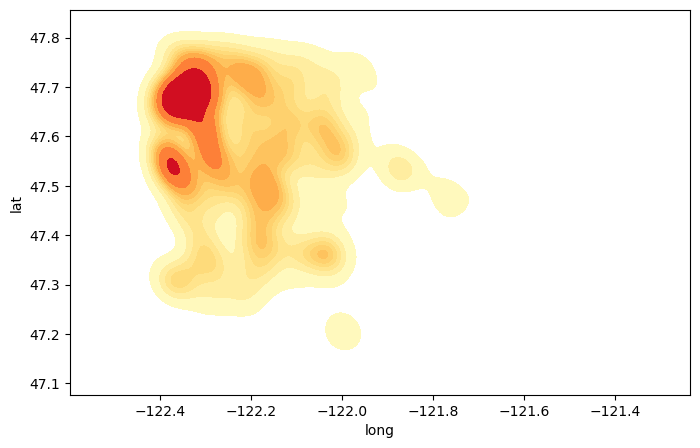

In [14]:
#plt.figure(figsize=(10,6))
sns.kdeplot(data=df_all, x='long', y='lat', cmap='YlOrRd', fill=True)

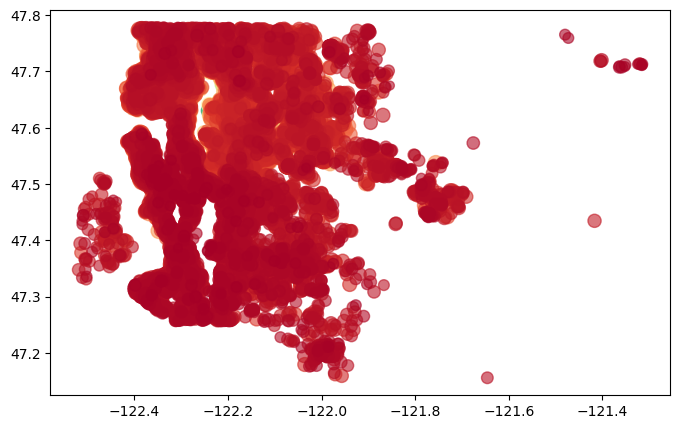

In [8]:
plt.scatter(df_all['long'], df_all['lat'], c=df_all['price'], s=df_all['grade']*10, 
            cmap='RdYlGn', alpha=0.6)